# JEET AC-Loss Calibration — Unified Pipeline Notebook

`jeet_acloss_rbf.AcLossPipeline` 기반의 단일 노트북. 예전의 모델별
`pyMotorCAD_Hybrid_AClossCode_ReducedRBF_{Ref,HalfSC,SC}[_Modular]` 노트북을
대체한다 (원본은 `legacy/`에 백업).

- **채택 설정 내장** (paper rev3): base@16 kRPM 커널, Ref donor 34 pts,
  HalfSC/SC 상사 전달(자체 25/23 pts), SC 이상점 제외
- 데이터 생성(Motor-CAD FEA sweep)은 여전히
  `pyMotorCAD_Hybrid_AClossCode_Template.ipynb` 담당 — 이 노트북은 그
  결과 JSON을 소비한다
- MATLAB에서는 `pybridge\demo_jeet_pipeline.m` 로 동일 워크플로 실행 가능


In [1]:
# [1] Setup
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
while repo_root.name and repo_root.name not in ("EveryMotor", "NvidiaNemo"):
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "eMach" / "tools"))

import numpy as np
import matplotlib.pyplot as plt

from jeet_acloss_rbf import AcLossPipeline, AcLossPlotter

MODEL_SCALE = 'SC'          # 'Ref' | 'HalfSC' | 'SC'
OUT_DIR = Path('map_exports/e10/figs')

pl = AcLossPipeline()
print('plan:', pl.cfg['plan'][MODEL_SCALE])

plan: {'mode': 'transfer', 'n_base': 22, 'n_spd': 3, 'seed': 2}


## [2] Dataset — 로드 & 육안 확인
채택 config의 데이터 품질 제외점이 자동 적용된다.

  [OK] Model scale check: backup_dir confirms all 239 records belong to SC
  [EXCLUDE] known-bad TS-FEA point dropped: 16000 RPM, 690.0 A, 90.0 deg

[누락 포인트 진단]
  2000RPM  AF 필터 제거 12건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (230.1, 0.0), (230.1, 18.0), (460.1, 0.0), (690.0, 0.0), (920.0, 0.0), (920.0, 18.0)]
  4000RPM  AF 필터 제거 7건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (920.0, 0.0)]
  8000RPM  AF 필터 제거 6건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0)]
  16000RPM  FEA 미완료 1건: [(460.1, 90.0)]
  16000RPM  AF 필터 제거 7건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (690.0, 90.0)]
AF 매칭 계산 완료: 87개 운전점
AF 범위: min=0.8069,  max=2.9032,  mean=1.5024
SC: 87 pts | AF [0.81, 2.90]


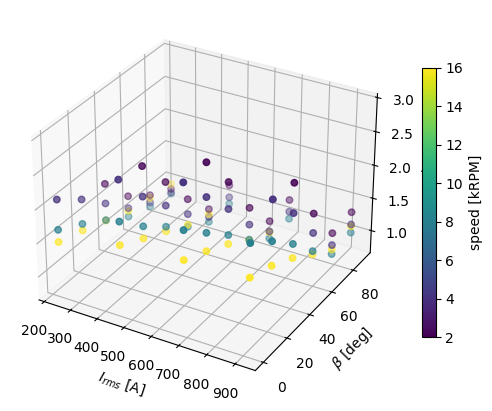

In [2]:
d = pl.dataset_struct(MODEL_SCALE)
print(f"{MODEL_SCALE}: {len(d['af'])} pts | "
      f"AF [{d['af'].min():.2f}, {d['af'].max():.2f}]")

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(d['irms_A'], d['phase_deg'], d['af'],
                c=d['speed_rpm'] / 1000, s=22, cmap='viridis')
ax.set_xlabel('$I_{rms}$ [A]'); ax.set_ylabel(r'$\beta$ [deg]')
ax.set_zlabel('AF'); fig.colorbar(sc, label='speed [kRPM]', shrink=0.7)
plt.show()

## [3] 데이터 품질 — AF 이웃 일관성 스캔
미수렴 TS-FEA 검출 (채택 제외점 적용 후에는 0이어야 정상).

In [3]:
flags = pl.scan_outliers(MODEL_SCALE)
print(f'outliers: {len(flags)}')
for f in flags:
    print(f"  {f['speed_rpm']:.0f} RPM  {f['irms_A']:.0f} A  "
          f"beta={f['phase_deg']:.0f}  AF={f['af']:.3f} "
          f"(expected ~{f['af_expected']:.3f}, dev {f['dev_pct']:+.0f}%)")

outliers: 0


## [4] 채택 모델 & 지표 (3모델 비교)
wMAE = 손실 가중 오차 — 효율맵 수준 정확도의 대표 지표.

In [4]:
rows = []
for s in ('Ref', 'HalfSC', 'SC'):
    m = pl.metrics(s)
    rows.append((s, m['n_points'], m['n_own_samples'],
                 m['hybrid_wmae_pct'], m['mae_pct'], m['wmae_pct']))
print(f"{'model':8s} {'pts':>4s} {'own':>4s} "
      f"{'hyb wMAE':>9s} {'MAE':>7s} {'wMAE':>7s}")
for r in rows:
    print(f'{r[0]:8s} {r[1]:4.0f} {r[2]:4.0f} {r[3]:8.1f}% '
          f'{r[4]:6.1f}% {r[5]:6.1f}%')

  [OK] Model scale check: backup_dir confirms all 240 records belong to Ref

[누락 포인트 진단]
  2000RPM  AF 필터 제거 14건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (115.1, 0.0), (230.0, 0.0), (230.0, 18.0), (345.0, 0.0), (345.0, 18.0), (460.0, 0.0), (460.0, 18.0), (460.0, 36.0)]
  4000RPM  AF 필터 제거 13건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (230.0, 0.0), (230.0, 18.0), (345.0, 0.0), (345.0, 18.0), (460.0, 0.0), (460.0, 18.0), (460.0, 36.0)]
  8000RPM  AF 필터 제거 11건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (230.0, 0.0), (345.0, 0.0), (345.0, 18.0), (460.0, 0.0), (460.0, 18.0)]
  16000RPM  AF 필터 제거 8건: [(0.1, 0.0), (0.1, 18.0), (0.1, 36.0), (0.1, 54.0), (0.1, 72.0), (0.1, 90.0), (345.0, 0.0), (460.0, 0.0)]
AF 매칭 계산 완료: 74개 운전점
AF 범위: min=0.8367,  max=2.8918,  mean=1.7556
  f( 2000 RPM): n=4  mean=1.3806  range=[1.3207, 1.4222]  p=1.078
  f( 4000 RPM): n=4  mean=1.2647  range=[1.1406, 

## [5] AF 예측 — 임의 운전점 / 스윕

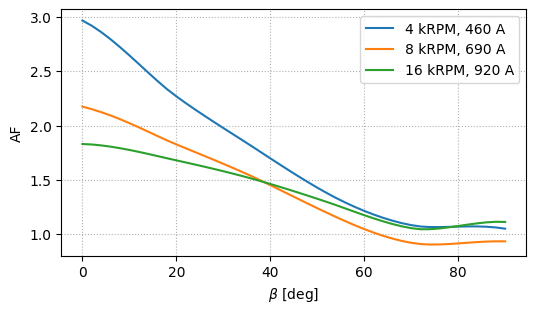

In [5]:
beta = np.arange(0, 91, 2.0)
fig, ax = plt.subplots(figsize=(6, 3.2))
for spd, cur in [(4000, 460), (8000, 690), (16000, 920)]:
    af = pl.predict_af(MODEL_SCALE, np.full_like(beta, spd),
                       np.full_like(beta, cur), beta)
    ax.plot(beta, af, label=f'{spd/1000:.0f} kRPM, {cur} A')
ax.set_xlabel(r'$\beta$ [deg]'); ax.set_ylabel('AF')
ax.grid(ls=':'); ax.legend(); plt.show()

## [6] AF 맵 시각화 (id–iq 평면 / 3D 표면)
기존 노트북 Cell 16/23의 시각화 — 패키지 함수 재사용.

> **주의 — 저속(2 kRPM) 패널이 실측과 어긋나 보이는 것은 의도된 분리성 잔차다.** AF의 동적 범위는 속도가 낮을수록 넓은데(2 k: 0.88–2.90, 16 k: 0.96–1.83), $AF = f_{1D}(\omega)\cdot g(I,\beta)$의 스칼라 $f_{1D}$는 평균만 조정할 뿐 스프레드는 바꾸지 못한다. 기준 커널을 16 kRPM에 앵커했으므로 잔차는 저속으로 밀려나며(모양 상관 0.997, 진폭만 압축), 2 k는 전체 와트의 1.7\%라 wMAE 기여는 0.28 %p에 불과하다. 전 속도 밀착 시각화가 필요하면 87점 전체를 보간하는 3D TPS RBF(LOOCV 2.4\%)를 대신 그릴 것.

D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:310: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:310: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:312: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches='tight')
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:312: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches='tight')


C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


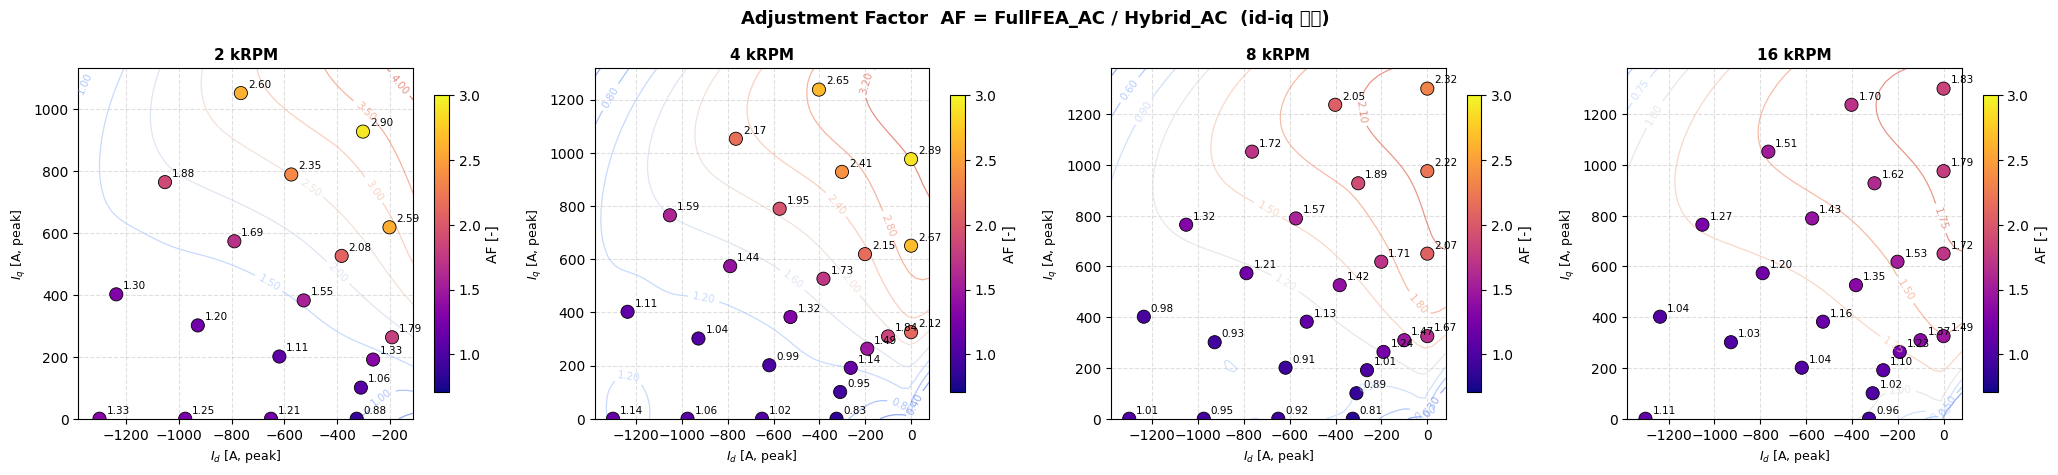

저장 완료: map_exports\e10\figs\AF_map_SC.png


D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:591: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:591: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:591: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:591: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:591: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:591: UserWarning: Glyph 46020 (\N{HANGUL SYLL

D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:593: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches="tight")
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:593: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches="tight")
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:593: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches="tight")
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:593: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=150, bbox_inches="tight")
D:\KangDH\EveryMotor\eMach\tools\jeet_acloss_rbf\AcLossPlotter.py:593: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.


C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\.ansys_python_venvs\pyMotorEnv_310\lib\site-packages\IPython\core\pylabtools.py:

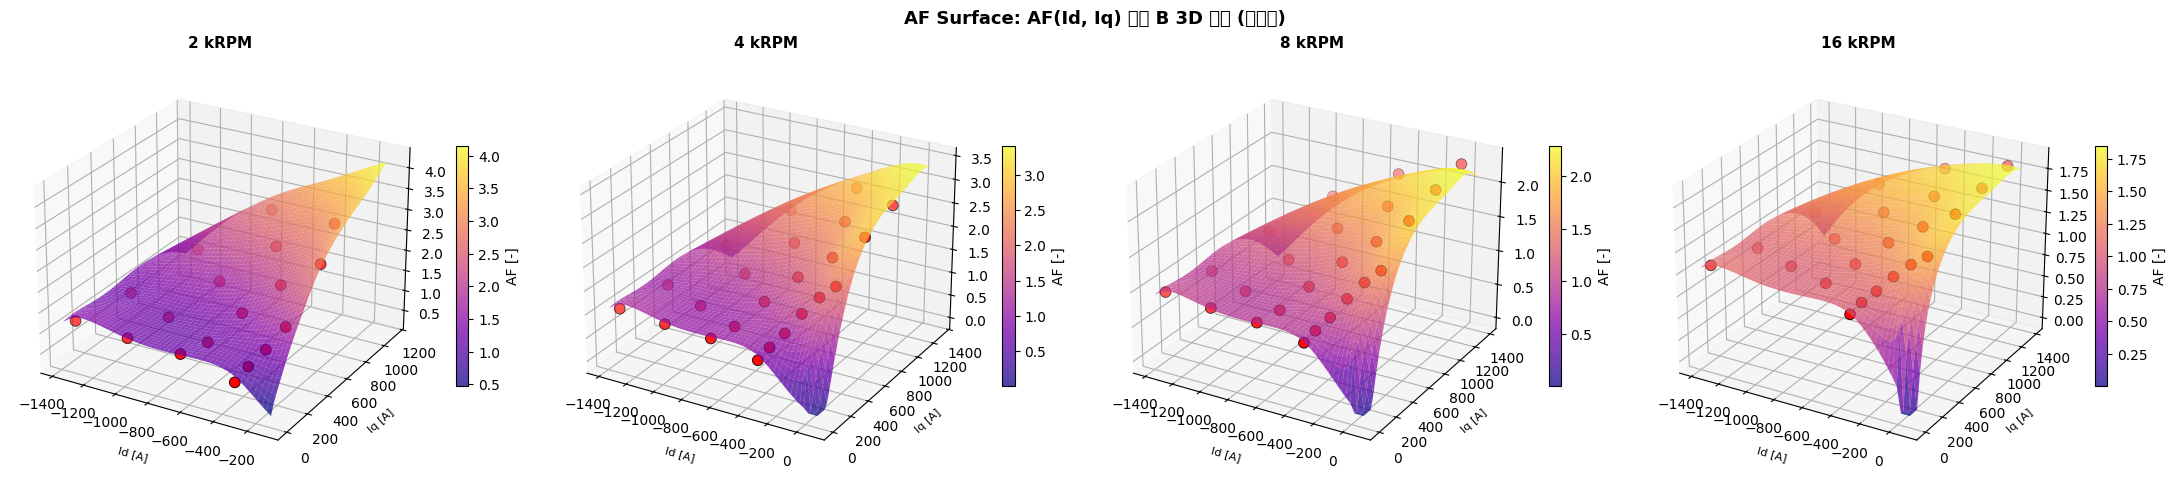

저장 완료: map_exports\e10\figs\AF_3D_SC.png


'map_exports\\e10\\figs\\AF_3D_SC.png'

In [6]:
pl.make_af_map_figure(MODEL_SCALE,
                      str(OUT_DIR / f'AF_map_{MODEL_SCALE}.png'))
pl.make_af_surface_figure(MODEL_SCALE,
                          str(OUT_DIR / f'AF_3D_{MODEL_SCALE}.png'))

## [7] SCL-M 상사성 검증 (변형체 ↔ Ref 사상)
$AF_{k_r}(\omega, I, \beta) = AF_{Ref}(k_r^2\omega, I/k_r, \beta)$ — 저속 대역 실측쌍 비교.

pairs: 39  mean|dev| = 3.20%  bias = -3.20%


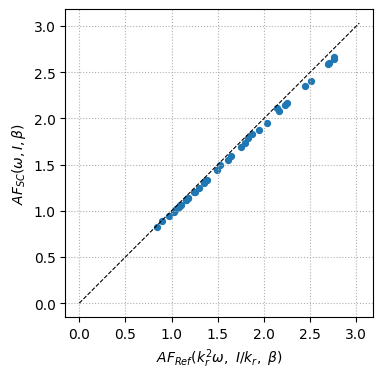

In [7]:
sim = pl.similarity_pairs('SC')
print(f"pairs: {len(sim['dev_pct'])}  "
      f"mean|dev| = {np.abs(sim['dev_pct']).mean():.2f}%  "
      f"bias = {sim['dev_pct'].mean():+.2f}%")

fig, ax = plt.subplots(figsize=(4, 4))
lim = [0, sim['af_ref_mapped'].max() * 1.1]
ax.plot(lim, lim, 'k--', lw=0.8)
ax.scatter(sim['af_ref_mapped'], sim['af_variant'], s=18)
ax.set_xlabel(r'$AF_{Ref}(k_r^2\omega,\ I/k_r,\ \beta)$')
ax.set_ylabel(r'$AF_{SC}(\omega, I, \beta)$')
ax.set_aspect('equal'); ax.grid(ls=':'); plt.show()

## [8] Transfer 샘플링 플랜 ablation (~1분)
자체 샘플 = $n_{base}$@16k + $n_{spd8}$@8k; 저속은 donor 전달.

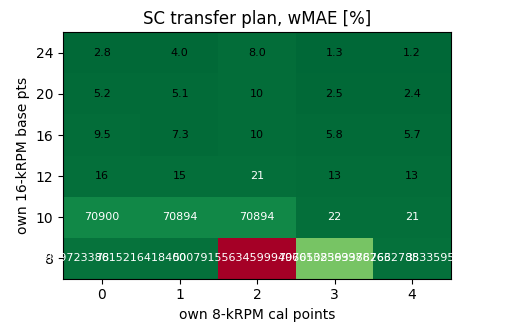

In [8]:
G = pl.transfer_ablation_grid(MODEL_SCALE)
fig, ax = plt.subplots(figsize=(5, 3.2))
im = ax.imshow(np.log10(G['wmae_pct']), cmap='RdYlGn_r',
               aspect='auto', origin='lower')
for bi in range(len(G['n_base'])):
    for si in range(len(G['n_spd8'])):
        v = G['wmae_pct'][bi, si]
        ax.text(si, bi, f'{v:.0f}' if v >= 10 else f'{v:.1f}',
                ha='center', va='center', fontsize=8,
                color='white' if np.log10(v) > 1.3 else 'black')
ax.set_xticks(range(len(G['n_spd8'])))
ax.set_xticklabels([int(v) for v in G['n_spd8']])
ax.set_yticks(range(len(G['n_base'])))
ax.set_yticklabels([int(v) for v in G['n_base']])
ax.set_xlabel('own 8-kRPM cal points'); ax.set_ylabel('own 16-kRPM base pts')
ax.set_title(f'{MODEL_SCALE} transfer plan, wMAE [%]')
plt.show()

## [9] 검증 그림 (논문 Fig 14 스타일) + 전체 재생성

In [9]:
pl.make_validation_figure(
    MODEL_SCALE, str(OUT_DIR / f'validation_{MODEL_SCALE}.png'))
# 논문용 일괄 재생성 후 Overleaf fig\ 로 복사:
# pl.make_all_figures(str(OUT_DIR))

'map_exports\\e10\\figs\\validation_SC.png'

## [10] Motor-CAD LAB 내보내기
채택 모델의 LAB 수식 — `runAFCustomLossLab.m` 파이프라인 입력.

In [10]:
model = pl.build_model(MODEL_SCALE)
print(model.mcad_formula[:400], '...')

Stator_Copper_Loss_AC * (
  ((+0.004086*(Speed/1000)**2-0.081445*(Speed/1000)+1.259145)) * (
    (-0.073510)*(((Stator_Current_Phase_RMS-690.0250)**2/65486.9901+(Phase_Advance-18.0000)**2/858.3496))*log(((Stator_Current_Phase_RMS-690.0250)**2/65486.9901+(Phase_Advance-18.0000)**2/858.3496)**0.5+1e-12) + (+0.096967)*(((Stator_Current_Phase_RMS-230.0750)**2/65486.9901+(Phase_Advance-0.0000)**2/858.3 ...
